In [25]:
# IMPORTO LE LIBRERIE

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [26]:
# LETTURA E VISUALIZZAZIONE DEL DATASET

df = pd.read_csv('hotel_bookings_raw_data.csv')


df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [27]:
# CONTROLLO IL DTYPE DELLE COLONNE

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [28]:
# CONVERTO LE COLONNE RELATIVE ALLE DATE IN int64 PER VERIFICARE LA CORRELAZIONE CON LA COLONNA is_canceled

df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'],format="%Y-%m-%d")
df['reservation_day'] = df['reservation_status_date'].dt.day.astype('int64')
df['reservation_month'] = df['reservation_status_date'].dt.month.astype('int64')
df['reservation_year'] = df['reservation_status_date'].dt.year.astype('int64')
df['reservation_weekday'] = df['reservation_status_date'].dt.weekday.astype('int64')

df['arrival_date_month'] = pd.to_datetime(df['arrival_date_month'], format='%B').dt.month.astype('int64')


df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,reservation_day,reservation_month,reservation_year,reservation_weekday
0,Resort Hotel,0,342,2015,7,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,1,7,2015,2
1,Resort Hotel,0,737,2015,7,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,1,7,2015,2
2,Resort Hotel,0,7,2015,7,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,2,7,2015,3
3,Resort Hotel,0,13,2015,7,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,2,7,2015,3
4,Resort Hotel,0,14,2015,7,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,3,7,2015,4


In [29]:
# CREO LE DUMMY VARIABLES (ONE-HOT ENCODING) DELLE COLONNE hotel , deposit_typede e market_segmentposit_type

hotel_dummies = pd.get_dummies(df['hotel'])
df = pd.concat([df, hotel_dummies], axis=1)

deposit_dummies = pd.get_dummies(df['deposit_type'], drop_first=False)
df = pd.concat([df, deposit_dummies], axis=1)

market_segment_dummies = pd.get_dummies(df['market_segment'])
df = pd.concat([df, market_segment_dummies], axis=1)


df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,Non Refund,Refundable,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
0,Resort Hotel,0,342,2015,7,27,1,0,0,2,...,False,False,False,False,False,True,False,False,False,False
1,Resort Hotel,0,737,2015,7,27,1,0,0,2,...,False,False,False,False,False,True,False,False,False,False
2,Resort Hotel,0,7,2015,7,27,1,0,1,1,...,False,False,False,False,False,True,False,False,False,False
3,Resort Hotel,0,13,2015,7,27,1,0,1,1,...,False,False,False,False,True,False,False,False,False,False
4,Resort Hotel,0,14,2015,7,27,1,0,2,2,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,8,35,30,2,5,2,...,False,False,False,False,False,False,False,True,False,False
119386,City Hotel,0,102,2017,8,35,31,2,5,3,...,False,False,False,False,False,False,False,False,True,False
119387,City Hotel,0,34,2017,8,35,31,2,5,2,...,False,False,False,False,False,False,False,False,True,False
119388,City Hotel,0,109,2017,8,35,31,2,5,2,...,False,False,False,False,False,False,False,False,True,False


In [30]:
# CONTROLLO IL DTYPE DELLE COLONNE E LA CREAZIONE DELLE DUMMY VARIABLES

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 49 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  int64         
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

In [31]:
# CONTROLLO LA CORRELAZIONE DELLA COLONNA is_canceled CON LE ALTRE COLONNE

corr = df.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)

# VISUALIZZO LA CORRELAZIONE

corr

is_canceled                       1.000000
Non Refund                        0.481457
lead_time                         0.293123
Groups                            0.221859
City Hotel                        0.136531
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_month                0.011022
arrival_date_week_number          0.008148
Undefined                         0.005336
children                          0.005048
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
Online TA                        -0.006288
Refundable                       -0.011312
Aviation                         -0.013946
company                          -0.020642
Offline TA/TO                    -0.028472
babies                           -0.032491
reservation

In [32]:
# CREO UN NUOVO DATASET CON LE COLONNE CHE MI INTERESSANO, CON VALORE ASSOLUTO MAGGIORE DELLA CORRELAZIONE.
# AVENDO CREATO DELLE COLONNE CON LE DUMMY VARIABLES, HO ELIMINATO LA COLONNA CON IL VALORE ASSOLUTO DI CORRELAZIONE PIÙ BASSO, RIDUCENDO COSÌ IL NUMERO DI VARIABILI DUMMY A N−1 DOVE N E' IL NUMERO DI CATEGORIE DISTINTE PRESENTI NELLA COLONNA ORIGINALE

df2 = df[[
      'is_canceled',
      'Non Refund',
      'Refundable',
      'City Hotel',
      'lead_time',
      'previous_cancellations',
      'total_of_special_requests',
      'required_car_parking_spaces',
      'reservation_weekday',
      'booking_changes',
      'is_repeated_guest',
      'Groups',
      'Offline TA/TO',
      'Aviation',
      'Corporate',
      'Direct',
      'Complementary'
]]

# VISUALIZZO IL NUOVO DATASET

df2

,is_canceled,Non Refund,Refundable,City Hotel,lead_time,previous_cancellations,total_of_special_requests,required_car_parking_spaces,reservation_weekday,booking_changes,is_repeated_guest,Groups,Offline TA/TO,Aviation,Corporate,Direct,Complementary
0,0,False,False,False,342,0,0,0,2,3,0,False,False,False,False,True,False
1,0,False,False,False,737,0,0,0,2,4,0,False,False,False,False,True,False
2,0,False,False,False,7,0,0,0,3,0,0,False,False,False,False,True,False
3,0,False,False,False,13,0,0,0,3,0,0,False,False,False,True,False,False
4,0,False,False,False,14,0,1,0,4,0,0,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0,False,False,True,23,0,0,0,2,0,0,False,True,False,False,False,False
119386,0,False,False,True,102,0,2,0,3,0,0,False,False,False,False,False,False
119387,0,False,False,True,34,0,4,0,3,0,0,False,False,False,False,False,False
119388,0,False,False,True,109,0,0,0,3,0,0,False,False,False,False,False,False


In [33]:
# CONTROLLO IL DTYPE DELLE COLONNE E VERIFICO CHE NON CI SIANO VALORI NULL

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   is_canceled                  119390 non-null  int64
 1   Non Refund                   119390 non-null  bool 
 2   Refundable                   119390 non-null  bool 
 3   City Hotel                   119390 non-null  bool 
 4   lead_time                    119390 non-null  int64
 5   previous_cancellations       119390 non-null  int64
 6   total_of_special_requests    119390 non-null  int64
 7   required_car_parking_spaces  119390 non-null  int64
 8   reservation_weekday          119390 non-null  int64
 9   booking_changes              119390 non-null  int64
 10  is_repeated_guest            119390 non-null  int64
 11  Groups                       119390 non-null  bool 
 12  Offline TA/TO                119390 non-null  bool 
 13  Aviation                     

In [34]:
# CONTROLLO LE CORRELAZIONI TRA LE COLONNE PER EVITARE LA MULTICOLLINEARITA'

corr2 = df2[[
      'Non Refund',
      'Refundable',
      'City Hotel',
      'lead_time',
      'previous_cancellations',
      'total_of_special_requests',
      'required_car_parking_spaces',
      'reservation_weekday',
      'booking_changes',
      'is_repeated_guest',
      'Groups',
      'Offline TA/TO',
      'Aviation',
      'Corporate',
      'Direct',
      'Complementary'
    ]].corr()

# VISUALIZZO LE CORRELAZIONI

corr2

,Non Refund,Refundable,City Hotel,lead_time,previous_cancellations,total_of_special_requests,required_car_parking_spaces,reservation_weekday,booking_changes,is_repeated_guest,Groups,Offline TA/TO,Aviation,Corporate,Direct,Complementary
Non Refund,1.000000,-0.013752,0.172003,0.380179,0.143314,-0.268034,-0.094982,-0.149391,-0.119333,-0.058423,0.464153,0.130188,-0.016639,-0.038877,-0.126602,-0.029523
Refundable,-0.013752,1.000000,-0.042234,0.016587,-0.003803,-0.019964,0.009158,-0.011744,0.020991,-0.001514,0.063070,-0.016332,-0.001644,-0.003520,-0.008222,-0.002917
City Hotel,0.172003,-0.042234,1.000000,0.075381,-0.012292,-0.043390,-0.218873,-0.024452,-0.072820,-0.050421,0.038688,0.028868,0.031693,-0.045867,-0.131794,0.010896
lead_time,0.380179,0.016587,0.075381,1.000000,0.086042,-0.095712,-0.116451,-0.071834,0.000149,-0.124410,0.346275,0.146307,-0.041554,-0.165075,-0.174111,-0.067184
previous_cancellations,0.143314,-0.003803,-0.012292,0.086042,1.000000,-0.048384,-0.018492,-0.030030,-0.026993,0.082293,0.098718,0.016284,-0.001704,0.020561,-0.027930,0.012270
total_of_special_requests,-0.268034,-0.019964,-0.043390,-0.095712,-0.048384,1.000000,0.082626,0.059220,0.052833,0.013050,-0.272410,-0.193023,-0.025733,-0.092802,0.002042,0.036068
required_car_parking_spaces,-0.094982,0.009158,-0.218873,-0.116451,-0.018492,0.082626,1.000000,0.039827,0.065620,0.077090,-0.087798,-0.081529,-0.006764,0.043451,0.148107,0.016304
reservation_weekday,-0.149391,-0.011744,-0.024452,-0.071834,-0.030030,0.059220,0.039827,1.000000,0.032711,0.002333,-0.068363,-0.019212,0.001725,0.005649,0.031047,0.009675
booking_changes,-0.119333,0.020991,-0.072820,0.000149,-0.026993,0.052833,0.065620,0.032711,1.000000,0.012092,-0.006375,-0.046186,0.002768,0.028451,0.091988,0.013504
is_repeated_guest,-0.058423,-0.001514,-0.050421,-0.124410,0.082293,0.013050,0.077090,0.002333,0.012092,1.000000,-0.046397,-0.046677,0.060423,0.302076,0.061053,0.125002


In [35]:
# USO UN FILTRO PER VISUALIZZARE VALORI ASSOLUTI MAGGIORE DI 0.7
# NON ESSENDOCI RISULTATI POSITIVI, INCLUDO TUTTE LE COLONNE NEL MIO MODELLO

corr2[corr2.abs() > 0.7]

,Non Refund,Refundable,City Hotel,lead_time,previous_cancellations,total_of_special_requests,required_car_parking_spaces,reservation_weekday,booking_changes,is_repeated_guest,Groups,Offline TA/TO,Aviation,Corporate,Direct,Complementary
Non Refund,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Refundable,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City Hotel,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_of_special_requests,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_spaces,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reservation_weekday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_changes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_repeated_guest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# DEFINISCO LE VARIABILI DEL MODELLO DI REGRESSIONE LOGISTICA, CON y COME VARIABILE TARGET E X COME MATRICE

y = df2['is_canceled']

X = df2[[
      'Non Refund',
      'Refundable',
      'City Hotel',
      'lead_time',
      'previous_cancellations',
      'total_of_special_requests',
      'required_car_parking_spaces',
      'reservation_weekday',
      'booking_changes',
      'is_repeated_guest',
      'Groups',
      'Offline TA/TO',
      'Aviation',
      'Corporate',
      'Direct',
      'Complementary'
    ]]

In [37]:
# SPLITTO I DATI IN TRAIN E TEST IMPOSTANDO UN SEED

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)

In [38]:
# CREO IL MODELLO DI REGRESSIONE LOGISTICA

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
# VISUALIZZO L'INTERCETTA E I COEFFICENTI DEL MODELLO

print('Intercept:', log_reg.intercept_)
print('Coefficients:', log_reg.coef_)

Intercept: [0.30006517]
Coefficients: [[ 5.65810057e+00 -2.54190629e-01 -4.38693264e-02  4.28773467e-03
   1.79205290e+00 -7.39477865e-01 -5.73297957e+00 -1.44044712e-01
  -3.88782332e-01 -1.33474852e+00 -1.40397814e+00 -1.74709903e+00
  -6.31339300e-01 -1.47612717e+00 -1.18099964e+00 -1.37666145e+00]]


In [40]:
# PER VISUALIZZARE IL "PESO" DEI COEFFICENTI DEL MODELLO, HO CREATO UN DATAFRAME

list_coeff = abs(log_reg.coef_[0])
df_coeff = pd.DataFrame(list_coeff, index=X.columns).sort_values(by=0,ascending=False)
df_coeff

,0
required_car_parking_spaces,5.732980
Non Refund,5.658101
previous_cancellations,1.792053
Offline TA/TO,1.747099
Corporate,1.476127
Groups,1.403978
Complementary,1.376661
is_repeated_guest,1.334749
Direct,1.181000
total_of_special_requests,0.739478


In [41]:
# EFFETTUO LE PREVISIONI

y_pred = log_reg.predict(X_test)

In [42]:
# CREO LA MATRICE DI CONFUSIONE E VISUALIZZO IL RISULTATO

cm = metrics.confusion_matrix(y_test, y_pred)

cm

array([[20857,  1665],
       [ 5584,  7711]], dtype=int64)

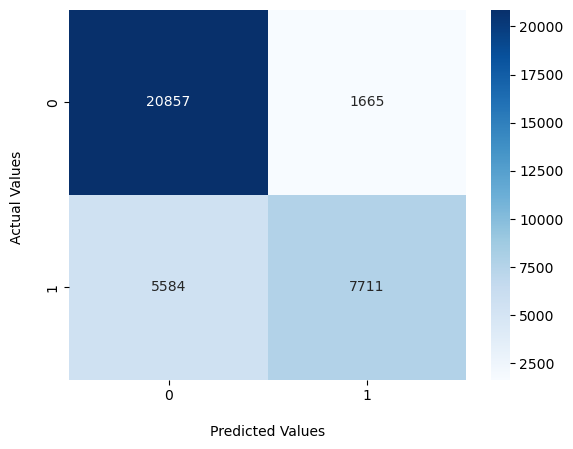

In [43]:
# CREO IL GRAFICO DELLA MATRICE DI CONFUSIONE

ax = sns.heatmap(cm, annot=True, cmap='Blues',fmt='d')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values \n')
ax.yaxis.set_ticklabels(['0','1'])
ax.xaxis.set_ticklabels(['0','1'])
plt.show()

In [44]:
# VISUALIZZO LE METRICHE DEL MODELLO

print('Precision score:',metrics.precision_score(y_test, y_pred))
print('Recall score:',metrics.recall_score(y_test, y_pred))
print('Accuracy score:',metrics.accuracy_score(y_test, y_pred))

Precision score: 0.8224189419795221
Recall score: 0.5799924783753291
Accuracy score: 0.7976100734288187


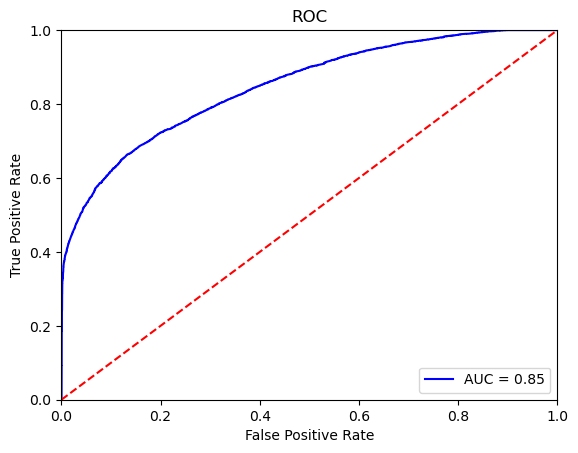

In [45]:
# CALCOLO LA ROC_AUC E VISUALIZZO IL GRAFICO

probs = log_reg.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)


plt.title('ROC')
plt.plot(fpr, tpr, 'b', label="AUC = %.2f" % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

COME RISULTATO OTTENGO CHE 85% DEI VALORI PREVISTI DAL MODELLO SONO CORRETTI

In [46]:
# AUMENTO LA SOGLIA DI CLASSIFICAZIONE A 0.65

y_pred2 = (log_reg.predict_proba(X_test)[:, 1] > 0.65).astype(int)

In [47]:
# VISUALIZZO LE METRICHE DEL MODELLO CON SOGLIA 0.65

print('Precision score:',metrics.precision_score(y_test, y_pred2))
print('Recall score:',metrics.recall_score(y_test, y_pred2))
print('Accuracy score:',metrics.accuracy_score(y_test, y_pred2))

Precision score: 0.9457089866801551
Recall score: 0.42188792779240314
Accuracy score: 0.7764190189016389


In [48]:
# VISUALIZZO LE METRICHE DEL MODELLO CON SOGLIA 0.5 E 0.65 IN UNA TABELLA

results = pd.DataFrame({
    'Metrica': ['Precision', 'Recall', 'Accuracy'],
    'Soglia 0.50 (y_pred)': [
        metrics.precision_score(y_test, y_pred),
        metrics.recall_score(y_test, y_pred),
        metrics.accuracy_score(y_test, y_pred)
    ],
    'Soglia 0.65 (y_pred2)': [
        metrics.precision_score(y_test, y_pred2),
        metrics.recall_score(y_test, y_pred2),
        metrics.accuracy_score(y_test, y_pred2)
    ]
}).set_index('Metrica')

print(results.round(4))

           Soglia 0.50 (y_pred)  Soglia 0.65 (y_pred2)
Metrica                                               
Precision                0.8224                 0.9457
Recall                   0.5800                 0.4219
Accuracy                 0.7976                 0.7764
